# 04 – Text Sentiment Model Experiments
**Project:** MoodSyncAI — Multi-Modal Sentiment & Emotion Analyser  
**Module:** Data Analytics-3

### Model
`cardiffnlp/twitter-roberta-base-sentiment-latest`  
RoBERTa-base trained on ~124M tweets (Jan 2018 – Dec 2021), fine-tuned on TweetEval.

### Output Label Space
| ID | Label    | Mapped To |
|----|----------|-----------|
| 0  | negative | Negative  |
| 1  | neutral  | Neutral   |
| 2  | positive | Positive  |

### Alignment With Visual Model
```
Visual (ResNet50V2 / 7 classes)      Text (RoBERTa / 3 classes)
────────────────────────────────     ──────────────────────────
Happy, Surprise          ────────►  Positive
Neutral                  ────────►  Neutral
Angry, Disgust, Fear, Sad────────►  Negative
```

### Objectives
1. Load and verify `cardiffnlp/twitter-roberta-base-sentiment-latest`
2. Explore the official preprocessing pipeline
3. Run inference on single texts and batch inputs
4. Evaluate on TweetEval sentiment test split
5. Analyse per-class confidence distributions
6. Test with MoodSyncAI-specific scenarios (mismatch cases)
7. Visualise attention weights (token-level importance)
8. Benchmark latency for real-time use
9. Define the production `get_text_sentiment()` function
10. Save model + tokenizer for use in `models/text/sentiment_model.py`

---

## 0 – Environment Setup & Imports

In [1]:
import os, sys, time, warnings, json
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.special import softmax

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    pipeline,
)
from datasets import load_dataset

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "cardiffnlp/twitter-roberta-base-sentiment-latest"
SAVE_DIR = Path("./saved_models/roberta_sentiment")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor":"#111111","axes.facecolor":"#1c1c1c",
    "axes.edgecolor":"#333333","axes.labelcolor":"#cccccc",
    "xtick.color":"#aaaaaa","ytick.color":"#aaaaaa",
    "text.color":"#e0e0e0","grid.color":"#2a2a2a",
    "grid.linestyle":"--","font.family":"DejaVu Sans",
})

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"Model   : {MODEL_ID}")

Python  : 3.11.13
PyTorch : 2.9.1+cu128
Device  : cuda
Model   : cardiffnlp/twitter-roberta-base-sentiment-latest


## 1 – Load Model, Tokenizer & Config

`AutoConfig` gives us the official `id2label` mapping straight from the model card,
so we never hard-code label names.

In [2]:
print(f"Loading tokenizer and model from HuggingFace Hub...")
t0 = time.time()

config    = AutoConfig.from_pretrained(MODEL_ID)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
model     = model.to(DEVICE)
model.eval()

print(f"Loaded in {time.time()-t0:.1f}s")
print(f"\nLabel mapping (from config.id2label):")
for idx, label in config.id2label.items():
    print(f"  {idx} -> {label}")

# Canonical label list: [negative, neutral, positive]
LABELS    = [config.id2label[i] for i in range(len(config.id2label))]
ID2LABEL  = config.id2label
LABEL2ID  = config.label2id
NUM_CLASSES = len(LABELS)
print(f"\nLABELS : {LABELS}")
print(f"Classes: {NUM_CLASSES}")

Loading tokenizer and model from HuggingFace Hub...
Loaded in 1.2s

Label mapping (from config.id2label):
  0 -> negative
  1 -> neutral
  2 -> positive

LABELS : ['negative', 'neutral', 'positive']
Classes: 3


## 2 – Official Preprocessing Function

The model was trained on tweets where usernames are replaced with `@user`
and URLs with `http`. Applying the same preprocessing at inference time
maintains the train/test distribution. [Source: cardiffnlp HuggingFace card]

In [3]:
def preprocess(text: str) -> str:
    """
    Replicate the preprocessing used during RoBERTa tweet training.
    - @username  -> @user
    - http://... -> http
    """
    new_tokens = []
    for token in text.split():
        if token.startswith("@") and len(token) > 1:
            new_tokens.append("@user")
        elif token.startswith("http"):
            new_tokens.append("http")
        else:
            new_tokens.append(token)
    return " ".join(new_tokens)

# ---- Test ----
test_cases = [
    "No, I think the project is going really well.",
    "I am so happy today! @john check this out https://example.com",
    "This is terrible. I hate everything.",
    "It was okay, nothing special.",
]
print("Preprocessing test:")
for t in test_cases:
    print(f"  IN : {t}")
    print(f"  OUT: {preprocess(t)}")
    print()

Preprocessing test:
  IN : No, I think the project is going really well.
  OUT: No, I think the project is going really well.

  IN : I am so happy today! @john check this out https://example.com
  OUT: I am so happy today! @user check this out http

  IN : This is terrible. I hate everything.
  OUT: This is terrible. I hate everything.

  IN : It was okay, nothing special.
  OUT: It was okay, nothing special.



## 3 – Core Inference Function

In [4]:
def get_text_sentiment(text: str,
                       model=model,
                       tokenizer=tokenizer,
                       config=config,
                       device=DEVICE,
                       max_len: int = 128) -> dict:
    """
    Run sentiment inference on a single text string.

    Parameters
    ----------
    text    : raw user input (preprocessing applied internally)
    max_len : max token length (RoBERTa supports up to 512)

    Returns
    -------
    dict with keys:
        label      : top predicted label  (e.g. "positive")
        confidence : confidence of top label  (0.0 – 1.0)
        probs      : {label: probability} for all 3 classes
        label_id   : integer index of top label
    """
    clean   = preprocess(text)
    encoded = tokenizer(
        clean,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_len,
    ).to(device)

    with torch.no_grad():
        logits = model(**encoded).logits          # (1, 3)
        scores = torch.softmax(logits, dim=-1)    # (1, 3)
        scores = scores.squeeze().cpu().numpy()   # (3,)

    top_id = int(np.argmax(scores))
    return {
        "label":      config.id2label[top_id],
        "label_id":   top_id,
        "confidence": round(float(scores[top_id]), 4),
        "probs": {
            config.id2label[i]: round(float(scores[i]), 4)
            for i in range(NUM_CLASSES)
        },
    }

# ---- Smoke test ----
demo_text = "No, I think the project is going really well."
result    = get_text_sentiment(demo_text)
print("Smoke test — assignment brief scenario:")
print(f"  Input : '{demo_text}'")
print(f"  Label : {result['label'].upper()}  ({result['confidence']*100:.1f}%)")
print(f"  Probs : {result['probs']}")

Smoke test — assignment brief scenario:
  Input : 'No, I think the project is going really well.'
  Label : POSITIVE  (96.7%)
  Probs : {'negative': 0.0056, 'neutral': 0.027, 'positive': 0.9673}


## 4 – Batch Inference Function

In [5]:
def get_text_sentiment_batch(texts: list,
                             model=model,
                             tokenizer=tokenizer,
                             config=config,
                             device=DEVICE,
                             batch_size: int = 32,
                             max_len: int = 128) -> list:
    results = []
    for i in range(0, len(texts), batch_size):
        batch_raw   = texts[i : i + batch_size]
        batch_clean = [preprocess(t) for t in batch_raw]

        encoded = tokenizer(
            batch_clean,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_len,
        ).to(device)

        with torch.no_grad():
            logits = model(**encoded).logits
            scores = torch.softmax(logits, dim=-1).cpu().numpy()  # (B, 3)

        for j, sc in enumerate(scores):
            top_id = int(np.argmax(sc))
            results.append({
                "text":       batch_raw[j],          # ← fix: j only, not i+j
                "label":      config.id2label[top_id],
                "label_id":   top_id,
                "confidence": round(float(sc[top_id]), 4),
                "probs": {
                    config.id2label[k]: round(float(sc[k]), 4)
                    for k in range(NUM_CLASSES)
                },
            })
    return results

print("get_text_sentiment_batch() defined.")

get_text_sentiment_batch() defined.


## 5 – Evaluation on TweetEval Sentiment Test Split

TweetEval is the exact benchmark used to fine-tune this model, so this section
gives us an honest measure of real-world accuracy before plugging into the
fusion pipeline.

In [6]:
print("Loading TweetEval sentiment dataset (test split)...")
tweet_ds = load_dataset("tweet_eval", "sentiment", split="test")
print(f"Test samples : {len(tweet_ds)}")
print(f"Label names  : {tweet_ds.features['label'].names}")

# TweetEval label mapping: 0=negative, 1=neutral, 2=positive  (same order as model)
TRUE_LABELS = tweet_ds.features["label"].names
print(f"\nFirst 3 samples:")
for ex in tweet_ds.select(range(3)):
    print(f"  [{TRUE_LABELS[ex['label']]}] {ex['text'][:80]}")

Loading TweetEval sentiment dataset (test split)...
Test samples : 12284
Label names  : ['negative', 'neutral', 'positive']

First 3 samples:
  [neutral] @user @user what do these '1/2 naked pics' have to do with anything? They're not
  [neutral] OH: “I had a blue penis while I was this” [playing with Google Earth VR]
  [neutral] @user @user That's coming, but I think the victims are going to be Medicaid reci


In [7]:
# Run batch inference on the full test set
print(f"Running inference on {len(tweet_ds)} test samples...")
t0      = time.time()
texts   = tweet_ds["text"]
preds   = get_text_sentiment_batch(texts, batch_size=64)
elapsed = time.time() - t0

pred_labels = [p["label_id"] for p in preds]
true_labels = tweet_ds["label"]

correct = sum(p == t for p, t in zip(pred_labels, true_labels))
acc     = correct / len(true_labels)

print(f"\nEvaluation complete in {elapsed:.1f}s  ({len(tweet_ds)/elapsed:.0f} samples/sec)")
print(f"Overall Accuracy : {acc*100:.2f}%  ({correct}/{len(true_labels)})")

Running inference on 12284 test samples...

Evaluation complete in 7.6s  (1622 samples/sec)
Overall Accuracy : 72.22%  (8872/12284)


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nPer-class metrics:")
print(classification_report(true_labels, pred_labels,
                             target_names=["negative","neutral","positive"],
                             digits=4))


Per-class metrics:
              precision    recall  f1-score   support

    negative     0.6899    0.8072    0.7439      3972
     neutral     0.7571    0.6579    0.7040      5937
    positive     0.7103    0.7411    0.7253      2375

    accuracy                         0.7222     12284
   macro avg     0.7191    0.7354    0.7244     12284
weighted avg     0.7263    0.7222    0.7211     12284



## 6 – Confusion Matrix

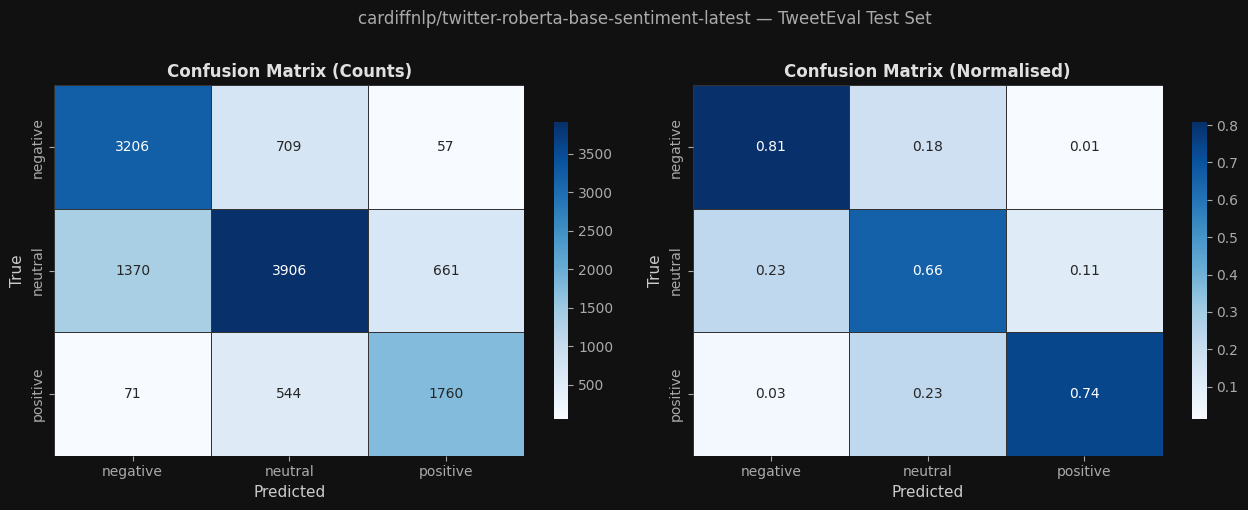

Saved: docs/text_confusion_matrix.png


In [10]:
cm      = confusion_matrix(true_labels, pred_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix (Counts)", "Confusion Matrix (Normalised)"],
    ["d", ".2f"],
):
    sns.heatmap(data, annot=True, fmt=fmt, ax=ax, cmap="Blues",
                xticklabels=["negative","neutral","positive"],
                yticklabels=["negative","neutral","positive"],
                linewidths=0.5, linecolor="#333333",
                cbar_kws={"shrink":0.8})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.set_title(title,        fontsize=12, fontweight="bold", color="#e0e0e0")

plt.suptitle("cardiffnlp/twitter-roberta-base-sentiment-latest — TweetEval Test Set",
             fontsize=12, color="#aaaaaa", y=1.01)
plt.tight_layout()
plt.savefig("./docs/text_confusion_matrix.png", dpi=150,
            bbox_inches="tight", facecolor="#111111")
plt.show()
print("Saved: docs/text_confusion_matrix.png")

## 7 – Confidence Distribution Per Class

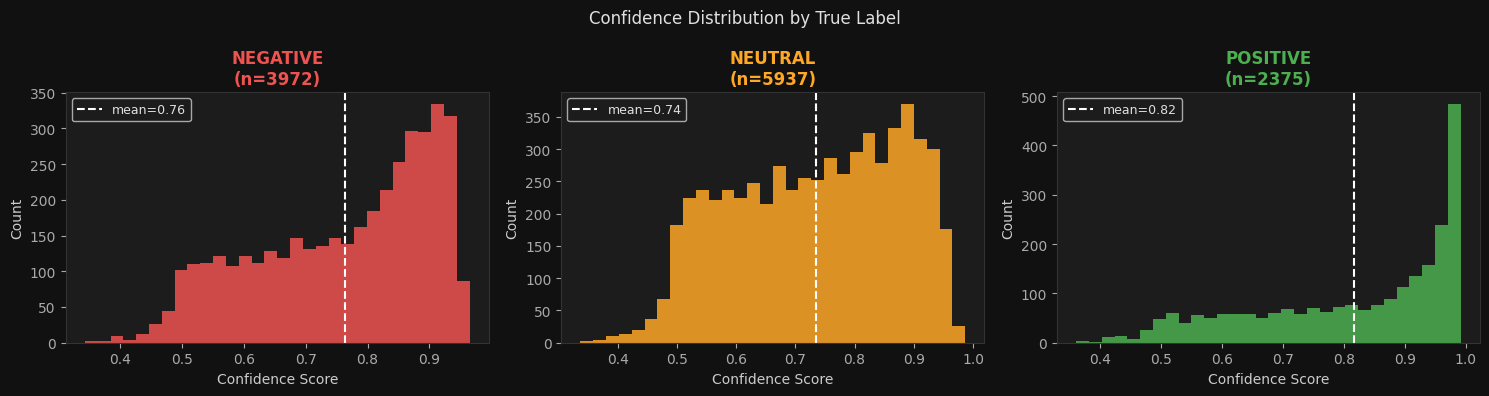

Saved: docs/text_confidence_dist.png


In [13]:
conf_by_class = {label: [] for label in ["negative","neutral","positive"]}
label_names   = ["negative","neutral","positive"]

for p, t in zip(preds, true_labels):
    conf_by_class[label_names[t]].append(p["confidence"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colours   = {"negative":"#EF5350", "neutral":"#FFA726", "positive":"#4CAF50"}

for ax, cls in zip(axes, ["negative","neutral","positive"]):
    data = conf_by_class[cls]
    ax.hist(data, bins=30, color=colours[cls], alpha=0.85, edgecolor="none")
    ax.axvline(np.mean(data), color="white", linestyle="--", linewidth=1.5,
               label=f"mean={np.mean(data):.2f}")
    ax.set_title(f"{cls.upper()}\n(n={len(data)})",   # ← fix: \n not a literal newline
                 fontweight="bold", color=colours[cls])
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Confidence Distribution by True Label", fontsize=12, color="#e0e0e0")
plt.tight_layout()
plt.savefig("./docs/text_confidence_dist.png", dpi=150,
            bbox_inches="tight", facecolor="#111111")
plt.show()
print("Saved: docs/text_confidence_dist.png")

## 8 – MoodSyncAI Scenario Tests

Testing the exact type of inputs the fusion layer will receive — including the
assignment brief scenario and edge cases that probe the mismatch detector.

In [14]:
scenarios = [
    # (description, text, expected_label)
    ("Assignment brief scenario",
     "No, I think the project is going really well.",
     "positive"),
    ("Clear positive — joy",
     "I just got promoted! Best day ever!",
     "positive"),
    ("Clear negative — sadness",
     "I can't stop crying. I feel so lost.",
     "negative"),
    ("Clear negative — anger",
     "This is absolutely unacceptable. I am furious.",
     "negative"),
    ("Ambiguous / masked emotion",
     "Everything is fine, I'm not upset at all.",
     "neutral"),
    ("Neutral factual statement",
     "The meeting is scheduled for Thursday at 3pm.",
     "neutral"),
    ("Polite suppression (social masking)",
     "It's okay, don't worry about it.",
     "neutral"),
    ("Strong mismatch trigger — fear face + positive text",
     "Don't worry, I'm completely fine with this decision.",
     "positive"),
    ("Tweet with mention and URL",
     "Check out @john's new post http://example.com — really inspiring!",
     "positive"),
    ("Sarcasm edge case",
     "Oh great, another Monday. Just what I needed.",
     "negative"),
]

print(f"{'#':<3} {'Expected':<10} {'Predicted':<10} {'Conf':>6}  {'Text[:55]'}")
print("-"*80)
correct_count = 0
for i, (desc, text, expected) in enumerate(scenarios, 1):
    r    = get_text_sentiment(text)
    ok   = "✓" if r["label"] == expected else "✗"
    if r["label"] == expected:
        correct_count += 1
    print(f"{i:<3} {expected:<10} {r['label']:<10} {r['confidence']*100:>5.1f}%  {ok}  {text[:55]}")

print(f"\nScenario accuracy: {correct_count}/{len(scenarios)}")

#   Expected   Predicted    Conf  Text[:55]
--------------------------------------------------------------------------------
1   positive   positive    96.7%  ✓  No, I think the project is going really well.
2   positive   positive    98.7%  ✓  I just got promoted! Best day ever!
3   negative   negative    88.2%  ✓  I can't stop crying. I feel so lost.
4   negative   negative    93.8%  ✓  This is absolutely unacceptable. I am furious.
5   neutral    positive    75.1%  ✗  Everything is fine, I'm not upset at all.
6   neutral    neutral     95.0%  ✓  The meeting is scheduled for Thursday at 3pm.
7   neutral    positive    45.8%  ✗  It's okay, don't worry about it.
8   positive   positive    89.3%  ✓  Don't worry, I'm completely fine with this decision.
9   positive   positive    98.7%  ✓  Check out @john's new post http://example.com — really 
10  negative   positive    96.8%  ✗  Oh great, another Monday. Just what I needed.

Scenario accuracy: 7/10


## 9 – Per-Scenario Confidence Bar Charts (UI Preview)

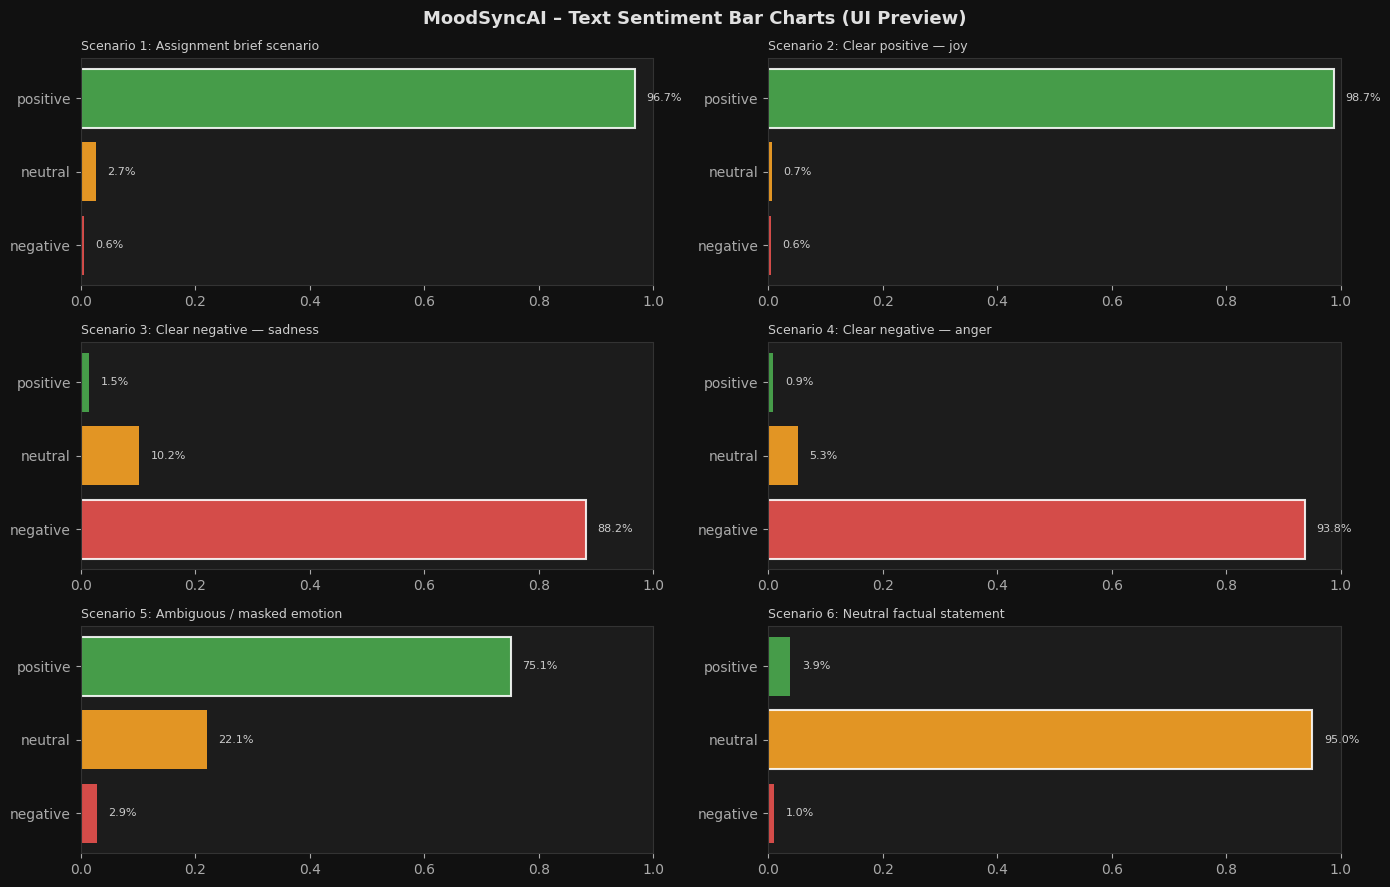

Saved: docs/text_scenario_bars.png


In [16]:
def plot_sentiment_bars(text, result, ax=None, title=None):
    """Render the 3-class confidence bar chart as it will appear in the Streamlit UI."""
    colours = {"negative":"#EF5350", "neutral":"#FFA726", "positive":"#4CAF50"}
    labels  = ["negative","neutral","positive"]
    probs   = [result["probs"][l] for l in labels]
    bar_c   = [colours[l] for l in labels]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 2.5))

    bars = ax.barh(labels, probs, color=bar_c, alpha=0.88, edgecolor="none")
    ax.set_xlim(0, 1)
    ax.set_title(title or f"'{text[:45]}...'",
                 fontsize=9, color="#cccccc", loc="left")
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.02, bar.get_y() + bar.get_height()/2,
                f"{w*100:.1f}%", va="center", fontsize=8, color="#cccccc")
    top_label = result["label"]
    ax.patches[labels.index(top_label)].set_edgecolor("white")
    ax.patches[labels.index(top_label)].set_linewidth(1.5)
    return ax

# Plot first 6 scenarios
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for i, (desc, text, expected) in enumerate(scenarios[:6]):
    r   = get_text_sentiment(text)
    row = i // 2; col = i % 2
    plot_sentiment_bars(text, r, ax=axes[row][col],
                        title=f"Scenario {i+1}: {desc}")

plt.suptitle("MoodSyncAI – Text Sentiment Bar Charts (UI Preview)",
             fontsize=13, fontweight="bold", color="#e0e0e0")
plt.tight_layout()
plt.savefig("./docs/text_scenario_bars.png", dpi=150,
            bbox_inches="tight", facecolor="#111111")
plt.show()
print("Saved: docs/text_scenario_bars.png")

## 10 – Attention Weight Visualisation

Visualise which tokens most influenced the sentiment prediction using the
last-layer average attention from the RoBERTa model.
This fulfils the optional "Attention visualisation" extended feature requirement.

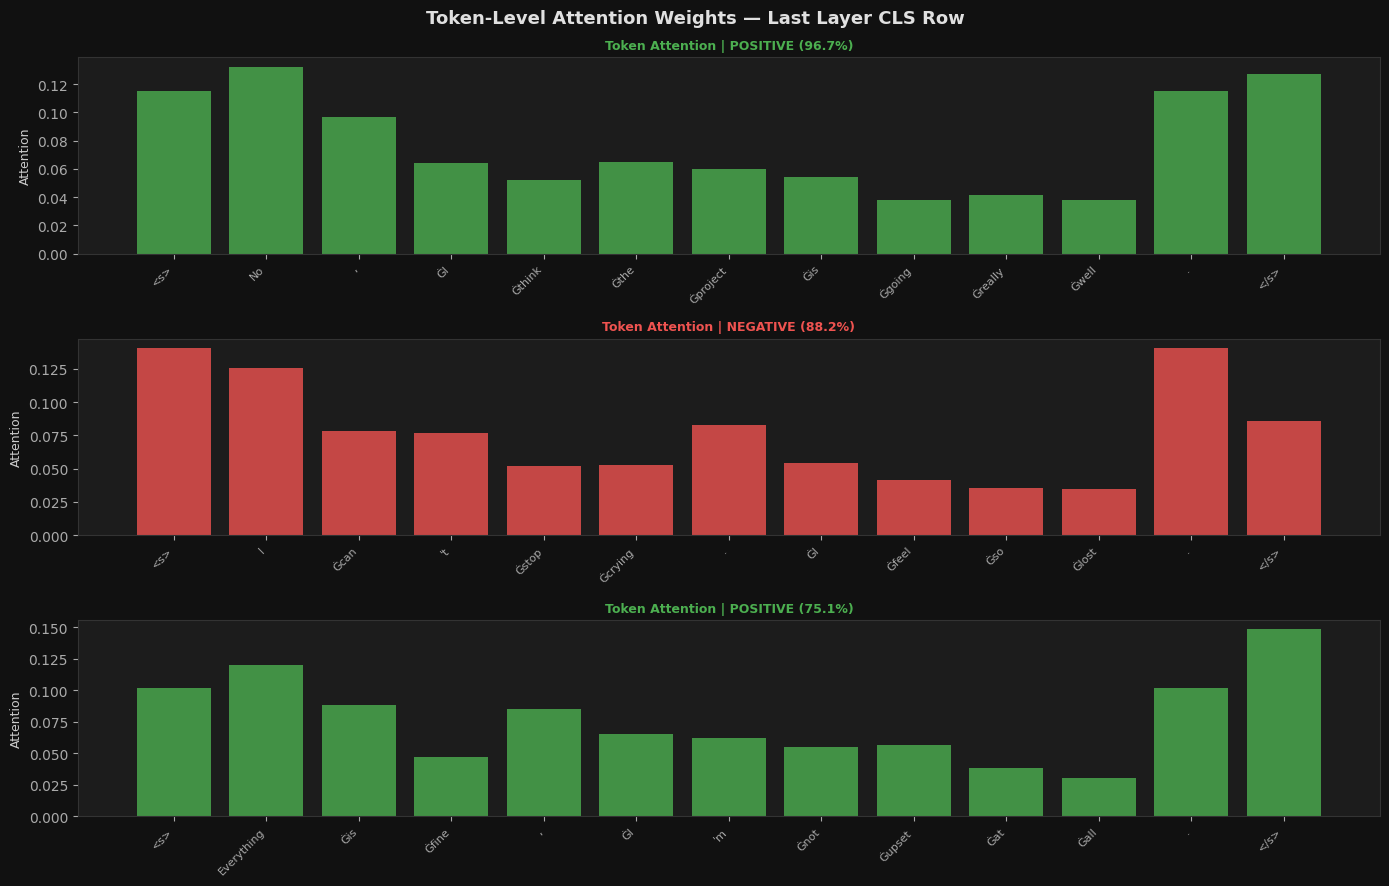

Saved: docs/text_attention_weights.png


In [17]:
def get_attention_weights(text: str,
                          model=model,
                          tokenizer=tokenizer,
                          device=DEVICE,
                          max_len: int = 128) -> dict:
    """
    Returns last-layer average attention over all heads for each token.
    """
    clean   = preprocess(text)
    encoded = tokenizer(clean, return_tensors="pt",
                        truncation=True, padding=True,
                        max_length=max_len).to(device)
    tokens  = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

    with torch.no_grad():
        outputs = model(**encoded, output_attentions=True)

    # Last layer attention: (1, num_heads, seq_len, seq_len)
    last_attn = outputs.attentions[-1]                          # (1, H, L, L)
    avg_attn  = last_attn.squeeze(0).mean(0)                   # (L, L)
    cls_attn  = avg_attn[0, :].cpu().numpy()                   # CLS row (L,)

    # Normalise
    cls_attn  = cls_attn / cls_attn.sum()
    return {"tokens": tokens, "attention": cls_attn}

def plot_token_attention(text: str, ax=None, title=None):
    """Colour-coded token bar chart weighted by CLS attention."""
    attn_data = get_attention_weights(text)
    tokens    = attn_data["tokens"]
    attention = attn_data["attention"]
    result    = get_text_sentiment(text)

    col_map   = {"negative":"#EF5350","neutral":"#FFA726","positive":"#4CAF50"}
    bar_col   = col_map[result["label"]]

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(8, len(tokens)*0.5), 2.5))

    ax.bar(range(len(tokens)), attention, color=bar_col, alpha=0.8, edgecolor="none")
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Attention", fontsize=9)
    ax.set_title(title or f"Token Attention | {result['label'].upper()} ({result['confidence']*100:.1f}%)",
                 fontsize=9, color=bar_col, fontweight="bold")
    return ax

# ---- Plot attention for 3 key scenarios ----
attn_texts = [
    "No, I think the project is going really well.",
    "I can't stop crying. I feel so lost.",
    "Everything is fine, I'm not upset at all.",
]
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, text in zip(axes, attn_texts):
    plot_token_attention(text, ax=ax)

plt.suptitle("Token-Level Attention Weights — Last Layer CLS Row",
             fontsize=13, fontweight="bold", color="#e0e0e0")
plt.tight_layout()
plt.savefig("./docs/text_attention_weights.png", dpi=150,
            bbox_inches="tight", facecolor="#111111")
plt.show()
print("Saved: docs/text_attention_weights.png")

## 11 – Polarity Fusion Bridge

Defines the mapping function used by the fusion layer to align the visual
7-class output with the text 3-class output before mismatch detection.

In [18]:
# Visual model 7 classes (from Face-emotion-detection.ipynb)
VISUAL_CLASSES  = ["Angry","Disgust","Fear","Happy","Neutral","Sad","Surprise"]

# Polarity mapping: visual class -> sentiment polarity
VISUAL_TO_POLARITY = {
    "Happy":    "positive",
    "Surprise": "positive",
    "Neutral":  "neutral",
    "Angry":    "negative",
    "Disgust":  "negative",
    "Fear":     "negative",
    "Sad":      "negative",
}

def get_visual_polarity(visual_pred: str) -> str:
    """Convert visual emotion label to 3-class polarity."""
    return VISUAL_TO_POLARITY.get(visual_pred, "neutral")

def detect_sentiment_mismatch(visual_pred: str,
                               text_pred: str,
                               visual_conf: float,
                               text_conf: float,
                               conf_threshold: float = 0.50) -> dict:
    """
    Detect mismatch between visual emotion and text sentiment polarity.

    Only flags MISMATCH when both modalities exceed the confidence threshold
    to avoid false positives on uncertain predictions.

    Severity:
        MATCH         -- both polarities agree
        SOFT_MISMATCH -- one modality is uncertain (below threshold)
        HARD_MISMATCH -- both confident but polarities oppose
    """
    visual_polarity = get_visual_polarity(visual_pred)
    text_polarity   = text_pred  # already in {negative, neutral, positive}
    polarity_match  = visual_polarity == text_polarity

    both_confident  = (visual_conf >= conf_threshold) and (text_conf >= conf_threshold)

    if polarity_match:
        severity = "MATCH"
    elif both_confident:
        severity = "HARD_MISMATCH"
    else:
        severity = "SOFT_MISMATCH"

    badge = {"MATCH":"#4CAF50","SOFT_MISMATCH":"#FFA726","HARD_MISMATCH":"#EF5350"}

    return {
        "severity":         severity,
        "badge_colour":     badge[severity],
        "visual_pred":      visual_pred,
        "visual_polarity":  visual_polarity,
        "text_pred":        text_polarity,
        "polarity_match":   polarity_match,
        "both_confident":   both_confident,
    }

# ---- Unit tests ----
test_pairs = [
    ("Happy",   0.80, "positive", 0.81, "MATCH"),
    ("Sad",     0.68, "positive", 0.81, "HARD_MISMATCH"),   # assignment brief
    ("Fear",    0.55, "neutral",  0.60, "HARD_MISMATCH"),
    ("Neutral", 0.72, "neutral",  0.75, "MATCH"),
    ("Sad",     0.35, "positive", 0.82, "SOFT_MISMATCH"),   # low visual conf
]
print(f"{'Visual':<10} {'VisConf':>7} {'Text':<10} {'TxtConf':>7}  {'Expected':<16} {'Got':<16} {'OK'}")
print("-"*80)
for vis_pred, vis_conf, txt_pred, txt_conf, expected in test_pairs:
    r  = detect_sentiment_mismatch(vis_pred, txt_pred, vis_conf, txt_conf)
    ok = "✓" if r["severity"] == expected else "✗"
    print(f"{vis_pred:<10} {vis_conf:>7.2f} {txt_pred:<10} {txt_conf:>7.2f}  {expected:<16} {r['severity']:<16} {ok}")

Visual     VisConf Text       TxtConf  Expected         Got              OK
--------------------------------------------------------------------------------
Happy         0.80 positive      0.81  MATCH            MATCH            ✓
Sad           0.68 positive      0.81  HARD_MISMATCH    HARD_MISMATCH    ✓
Fear          0.55 neutral       0.60  HARD_MISMATCH    HARD_MISMATCH    ✓
Neutral       0.72 neutral       0.75  MATCH            MATCH            ✓
Sad           0.35 positive      0.82  SOFT_MISMATCH    SOFT_MISMATCH    ✓


## 12 – Latency Benchmark

In [19]:
N_WARMUP  = 5
N_MEASURE = 50
test_text = "No, I think the project is going really well."

# Warmup
for _ in range(N_WARMUP):
    get_text_sentiment(test_text)

# Measure single-sample latency
times = []
for _ in range(N_MEASURE):
    t0 = time.perf_counter()
    get_text_sentiment(test_text)
    times.append((time.perf_counter() - t0) * 1000)   # ms

print(f"Single-sample latency ({DEVICE}):")
print(f"  Mean   : {np.mean(times):.1f} ms")
print(f"  Median : {np.median(times):.1f} ms")
print(f"  p95    : {np.percentile(times,95):.1f} ms")
print(f"  Min    : {np.min(times):.1f} ms")
print(f"  Max    : {np.max(times):.1f} ms")
print(f"\nReal-time suitability: {'✓ Yes' if np.median(times) < 500 else '✗ Consider batching'}  (target < 500ms)")

Single-sample latency (cuda):
  Mean   : 1.9 ms
  Median : 1.9 ms
  p95    : 1.9 ms
  Min    : 1.9 ms
  Max    : 2.1 ms

Real-time suitability: ✓ Yes  (target < 500ms)


## 13 – Save Model & Tokenizer

In [20]:
print(f"Saving model and tokenizer to: {SAVE_DIR}")
model.save_pretrained(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))

# Save metadata for use in production code
meta = {
    "model_id":           MODEL_ID,
    "save_dir":           str(SAVE_DIR),
    "labels":             LABELS,
    "id2label":           {str(k): v for k, v in ID2LABEL.items()},
    "label2id":           LABEL2ID,
    "num_classes":        NUM_CLASSES,
    "visual_to_polarity": VISUAL_TO_POLARITY,
    "preprocess":         "Replace @user and http tokens before tokenization",
    "max_len":            128,
    "conf_threshold":     0.50,
    "mismatch_levels":    ["MATCH","SOFT_MISMATCH","HARD_MISMATCH"],
}
meta_path = SAVE_DIR / "text_model_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved metadata: {meta_path}")
print(json.dumps(meta, indent=2))

Saving model and tokenizer to: saved_models/roberta_sentiment
Saved metadata: saved_models/roberta_sentiment/text_model_meta.json
{
  "model_id": "cardiffnlp/twitter-roberta-base-sentiment-latest",
  "save_dir": "saved_models/roberta_sentiment",
  "labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "id2label": {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
  },
  "label2id": {
    "negative": 0,
    "neutral": 1,
    "positive": 2
  },
  "num_classes": 3,
  "visual_to_polarity": {
    "Happy": "positive",
    "Surprise": "positive",
    "Neutral": "neutral",
    "Angry": "negative",
    "Disgust": "negative",
    "Fear": "negative",
    "Sad": "negative"
  },
  "preprocess": "Replace @user and http tokens before tokenization",
  "max_len": 128,
  "conf_threshold": 0.5,
  "mismatch_levels": [
    "MATCH",
    "SOFT_MISMATCH",
    "HARD_MISMATCH"
  ]
}


## 14 – Integration Snippet for `models/text/sentiment_model.py`

In [21]:
integration = """
# ─────────────────────────────────────────────────────────────────
# models/text/sentiment_model.py
# ─────────────────────────────────────────────────────────────────
import json
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from pathlib import Path

SAVE_DIR = Path("saved_models/roberta_sentiment")
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"


def preprocess(text: str) -> str:
    tokens = []
    for t in text.split():
        if t.startswith("@") and len(t) > 1:
            tokens.append("@user")
        elif t.startswith("http"):
            tokens.append("http")
        else:
            tokens.append(t)
    return " ".join(tokens)


class TextSentimentModel:
    def __init__(self, model_dir: str = str(SAVE_DIR)):
        self.config    = AutoConfig.from_pretrained(model_dir)
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model     = AutoModelForSequenceClassification.from_pretrained(model_dir)
        self.model     = self.model.to(DEVICE)
        self.model.eval()

    def predict(self, text: str, max_len: int = 128) -> dict:
        clean   = preprocess(text)
        enc     = self.tokenizer(clean, return_tensors="pt",
                                 truncation=True, padding=True,
                                 max_length=max_len).to(DEVICE)
        with torch.no_grad():
            scores = torch.softmax(self.model(**enc).logits, dim=-1)
            scores = scores.squeeze().cpu().numpy()
        top_id  = int(np.argmax(scores))
        return {
            "label":      self.config.id2label[top_id],
            "label_id":   top_id,
            "confidence": round(float(scores[top_id]), 4),
            "probs": {
                self.config.id2label[i]: round(float(scores[i]), 4)
                for i in range(len(scores))
            },
        }

# Usage in app/main.py:
#   from models.text.sentiment_model import TextSentimentModel
#   text_model = TextSentimentModel()
#   result     = text_model.predict(user_text)
# ─────────────────────────────────────────────────────────────────
"""
print(integration)


# ─────────────────────────────────────────────────────────────────
# models/text/sentiment_model.py
# ─────────────────────────────────────────────────────────────────
import json
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from pathlib import Path

SAVE_DIR = Path("saved_models/roberta_sentiment")
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"


def preprocess(text: str) -> str:
    tokens = []
    for t in text.split():
        if t.startswith("@") and len(t) > 1:
            tokens.append("@user")
        elif t.startswith("http"):
            tokens.append("http")
        else:
            tokens.append(t)
    return " ".join(tokens)


class TextSentimentModel:
    def __init__(self, model_dir: str = str(SAVE_DIR)):
        self.config    = AutoConfig.from_pretrained(model_dir)
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model     = AutoModelForSequenceClassifi

## 15 – Notebook Summary

In [22]:
print("="*64)
print("  04 Text Model — Key Decisions")
print("="*64)
summary = {
    "Model":                "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "Classes":              "negative (0) / neutral (1) / positive (2)",
    "Training data":        "~124M tweets Jan 2018 – Dec 2021",
    "Benchmark":            "TweetEval sentiment",
    "Preprocessing":        "@user and http token replacement",
    "Max token length":     "128 (sufficient for spoken sentences)",
    "Polarity bridge":      "Happy/Surprise→positive | Neutral→neutral | Angry/Disgust/Fear/Sad→negative",
    "Mismatch confidence":  "Both modalities ≥ 0.50 for HARD_MISMATCH",
    "Mismatch levels":      "MATCH / SOFT_MISMATCH / HARD_MISMATCH",
    "Saved artefacts":      "saved_models/roberta_sentiment/ + text_model_meta.json",
    "Docs saved":           "confusion_matrix, confidence_dist, scenario_bars, attention_weights",
}
for k, v in summary.items():
    print(f"  {k:<26}: {v}")
print("="*64)
print("\nNext step: run 05_fusion_analysis.ipynb")
print("  → import get_text_sentiment from this notebook's production snippet")
print("  → pair with ResNet50V2 visual output for fusion + mismatch detection")

  04 Text Model — Key Decisions
  Model                     : cardiffnlp/twitter-roberta-base-sentiment-latest
  Classes                   : negative (0) / neutral (1) / positive (2)
  Training data             : ~124M tweets Jan 2018 – Dec 2021
  Benchmark                 : TweetEval sentiment
  Preprocessing             : @user and http token replacement
  Max token length          : 128 (sufficient for spoken sentences)
  Polarity bridge           : Happy/Surprise→positive | Neutral→neutral | Angry/Disgust/Fear/Sad→negative
  Mismatch confidence       : Both modalities ≥ 0.50 for HARD_MISMATCH
  Mismatch levels           : MATCH / SOFT_MISMATCH / HARD_MISMATCH
  Saved artefacts           : saved_models/roberta_sentiment/ + text_model_meta.json
  Docs saved                : confusion_matrix, confidence_dist, scenario_bars, attention_weights

Next step: run 05_fusion_analysis.ipynb
  → import get_text_sentiment from this notebook's production snippet
  → pair with ResNet50V2 visual ou